In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [16]:
def getCSV(csv):
    dfl = pd.read_csv(csv)
    return dfl
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\EarningsNationality.csv') 
print(df)

     Statistic Label  Year        Nationality          Age Group UNIT    VALUE
0    Median Earnings  2023            Ireland           All ages    €   728.05
1    Median Earnings  2023            Ireland      15 - 24 years    €   335.25
2    Median Earnings  2023            Ireland      25 - 29 years    €   696.73
3    Median Earnings  2023            Ireland      30 - 39 years    €   872.10
4    Median Earnings  2023            Ireland      40 - 49 years    €   935.80
..               ...   ...                ...                ...  ...      ...
163    Mean Earnings  2023  All nationalities      25 - 29 years    €   742.57
164    Mean Earnings  2023  All nationalities      30 - 39 years    €   971.96
165    Mean Earnings  2023  All nationalities      40 - 49 years    €  1094.56
166    Mean Earnings  2023  All nationalities      50 - 59 years    €  1066.31
167    Mean Earnings  2023  All nationalities  60 years and over    €   805.65

[168 rows x 6 columns]


In [18]:
age = "All ages"
label = "Mean Earnings"
filtered_df = df[(df['Age Group']==age)&(df['Statistic Label']==label)]
filtered_df = filtered_df[filtered_df['Nationality']!="All nationalities"]

In [20]:
def changeNames(name):
    switch = {
        "United Kingdom of Great Britain and Northern Ireland (the)": "UK",
        "Other countries (2)": "Other"
    }
    if name not in switch:
        return name
    else:
        return switch[name]
filtered_df['Nationality'] = filtered_df['Nationality'].apply(changeNames)

    Statistic Label  Year Nationality Age Group UNIT    VALUE
84    Mean Earnings  2023     Ireland  All ages    €   915.76
91    Mean Earnings  2023      Poland  All ages    €   696.83
98    Mean Earnings  2023          UK  All ages    €  1020.68
105   Mean Earnings  2023       India  All ages    €  1023.39
112   Mean Earnings  2023     Romania  All ages    €   700.66
119   Mean Earnings  2023      Brazil  All ages    €   604.70
126   Mean Earnings  2023   Lithuania  All ages    €   641.73
133   Mean Earnings  2023       Spain  All ages    €   885.46
140   Mean Earnings  2023       Italy  All ages    €   973.53
147   Mean Earnings  2023     Ukraine  All ages    €   504.12
154   Mean Earnings  2023       Other  All ages    €   888.50


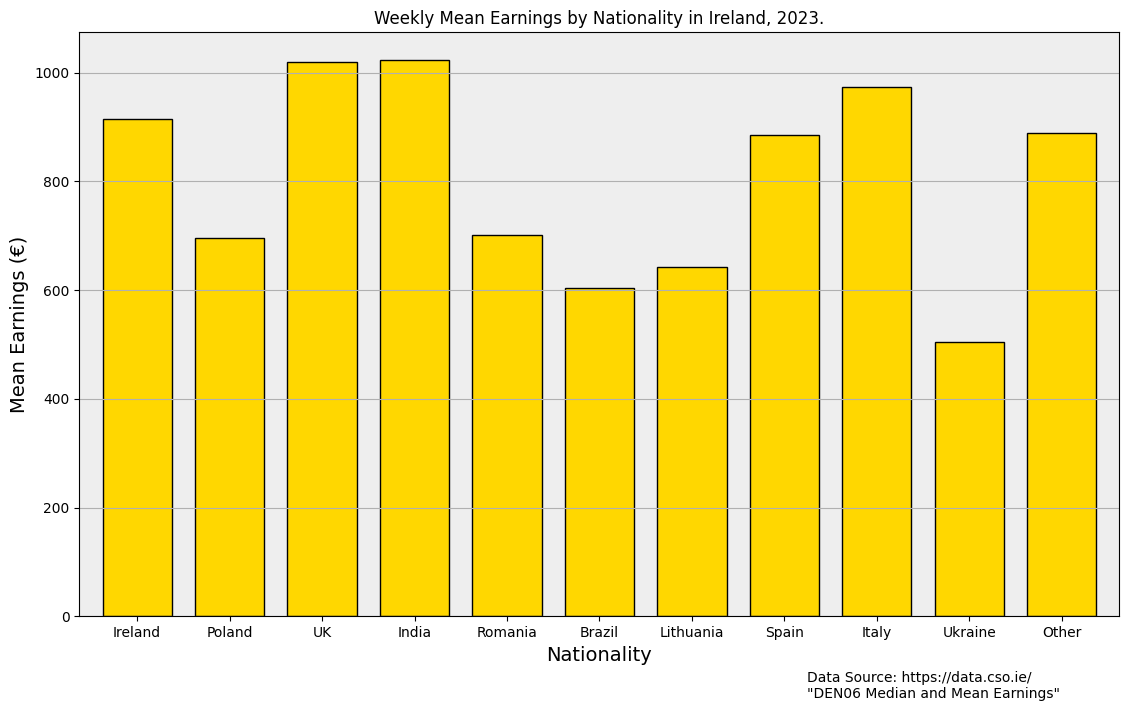

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(13, 8))

filtered_df.plot(x="Nationality", y="VALUE", kind="bar", width=0.75, edgecolor="black", color="#FFD700", ax=ax)

title_string = "Weekly " + label +" by Nationality in Ireland, 2023." 

plt.title(title_string)
plt.xlabel('Nationality', fontsize=14)
plt.ylabel(label+' (€)', fontsize=14)
plt.xticks(rotation=0) 
#ax.set_xlim(200,550)
ax.set_facecolor('#EEEEEE') 
ax.get_legend().remove()
plt.grid(True, axis="y")

plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.17)
plt.text(0.7, -0.14, "Data Source: https://data.cso.ie/ \n\"DEN06 Median and Mean Earnings\"", ha='left', transform=ax.transAxes)

save_fig = 'Nationality'+label+'.png'
plt.savefig(save_fig)

# Show the plot
plt.show()


In [21]:
#df_sorted = df.sort_values(by='Score', ascending=False)
df_sorted = filtered_df.sort_values(by='VALUE', ascending=False)
print(df_sorted)

    Statistic Label  Year Nationality Age Group UNIT    VALUE
105   Mean Earnings  2023       India  All ages    €  1023.39
98    Mean Earnings  2023          UK  All ages    €  1020.68
140   Mean Earnings  2023       Italy  All ages    €   973.53
84    Mean Earnings  2023     Ireland  All ages    €   915.76
154   Mean Earnings  2023       Other  All ages    €   888.50
133   Mean Earnings  2023       Spain  All ages    €   885.46
112   Mean Earnings  2023     Romania  All ages    €   700.66
91    Mean Earnings  2023      Poland  All ages    €   696.83
126   Mean Earnings  2023   Lithuania  All ages    €   641.73
119   Mean Earnings  2023      Brazil  All ages    €   604.70
147   Mean Earnings  2023     Ukraine  All ages    €   504.12
